In [1]:
import pandas as pd
import numpy as np
import xarray as xr

import statsmodels.api as sm

import matplotlib.pyplot as plt

from bluemath_tk.teslakit.alr import ALR_WRP

In [2]:
data = xr.open_dataset('/workspaces/BlueMath_Course_Corvallis/toolkit/data/outputs/era5_precip_newport_or_1940-01-01_to_2026-05-31_lat44.75_lon236.nc')
data = data.tp.to_dataframe()[['tp']]
data['tp_mm'] = data['tp'] * 1000

threshold = 1.0
data['rain'] = (data['tp_mm'] >= threshold).astype(float)
data = data.rename(columns={'rain':'bmus'})

In [3]:
data = data.rename_axis('time')

In [4]:
data['bmus'] = data['bmus'] + 1
data['bmus'] = data['bmus'].astype(int)

In [ ]:
alr_terms = {
    "mk_order": 0,
    "constant": True,
    "long_term": False,
    "seasonality": (True, [2]),
    "covariates": (
        False, []
    ),
}

rain_data_ds = data[['bmus']].to_xarray()

alr_model = ALR_WRP(p_base="outputs/alr")
alr_model.SetFitData(
    cluster_size=2,
    xds_bmus_fit=rain_data_ds,
    d_terms_settings=alr_terms,
)
alr_model.FitModel(max_iter=1000)


Fitting autoregressive logistic model ...
Optimization done in 0.07 seconds



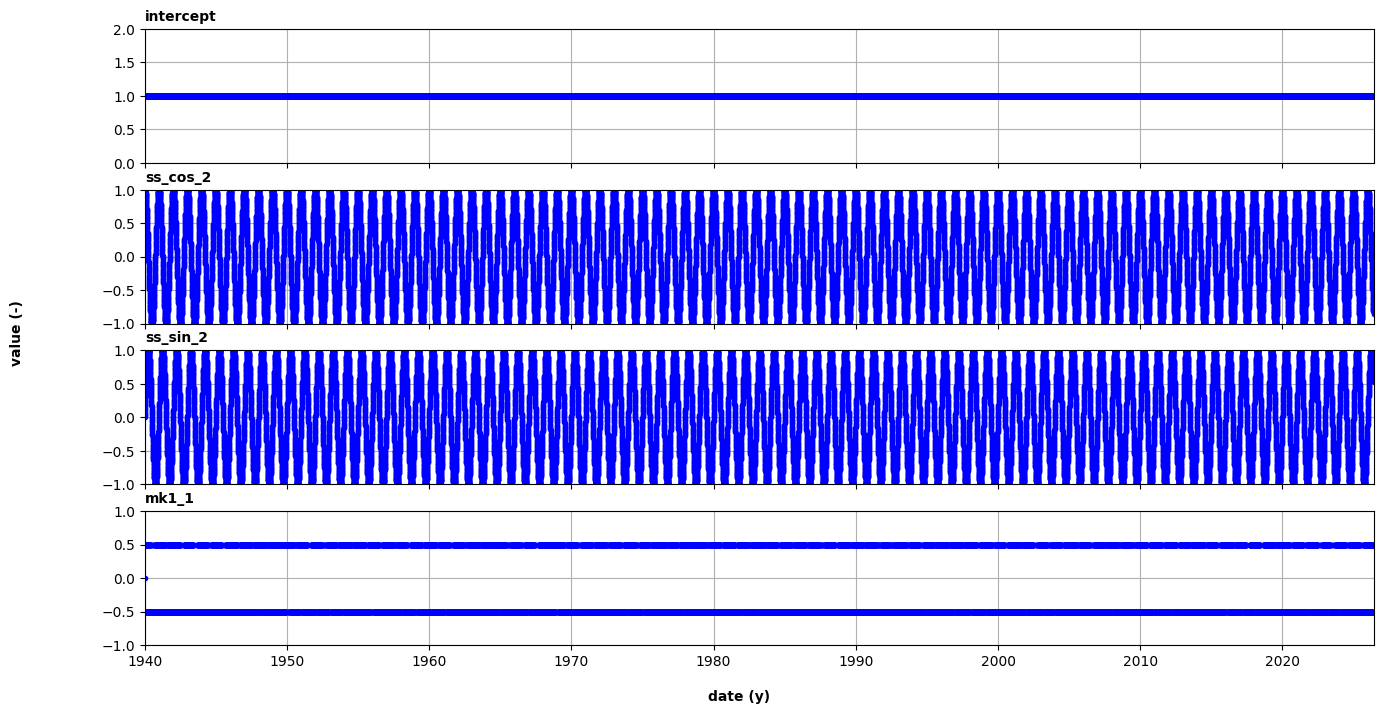

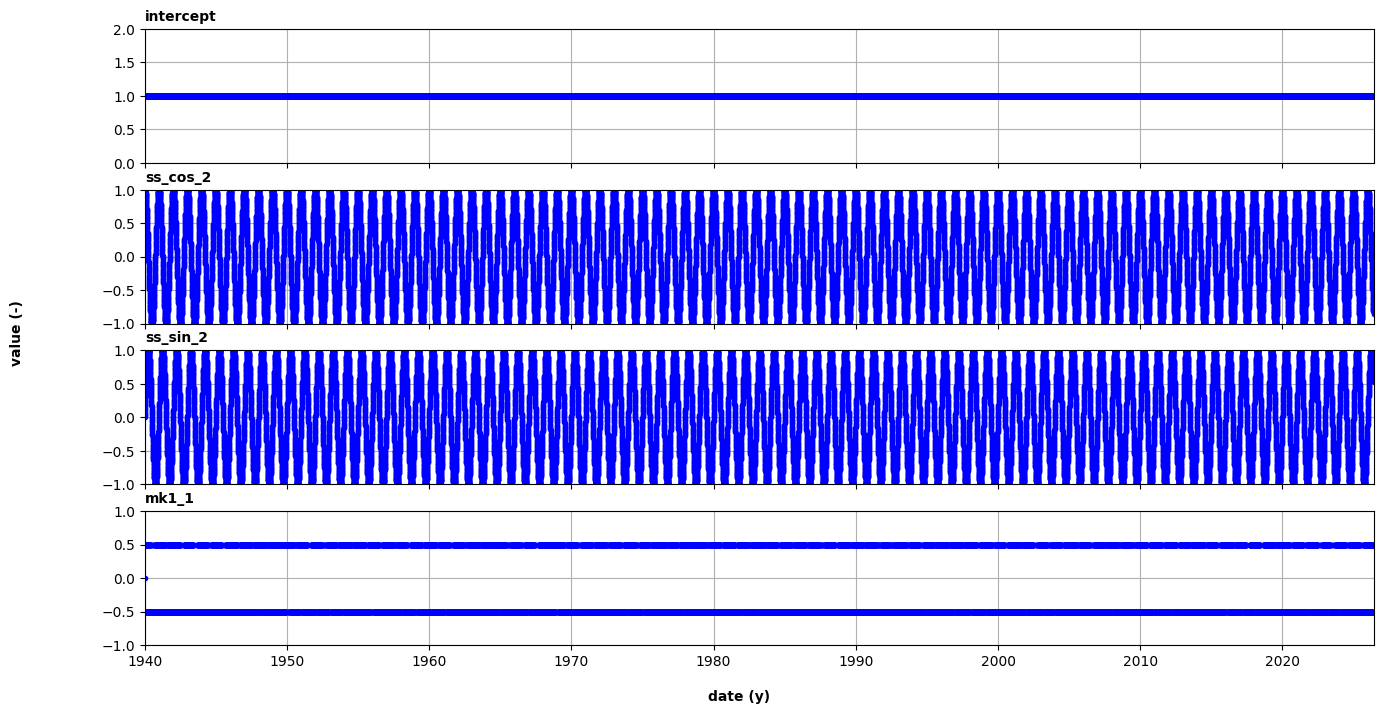

In [6]:
alr_model.Report_Terms_Fit()

In [7]:
alr_model.Simulate(num_sims=20, time_sim=data.index)

ALR model fit   : 1940-01-01 --- 2026-05-31
ALR model sim   : 1940-01-01 --- 2026-05-31

Launching 20 simulations...

Sim. Num. 020: 100%|██████████| 31562/31562 [00:02<00:00, 13015.56it/s]



<xarray.Dataset> Size: 6MB
Dimensions:      (time: 31563, n_sim: 20)
Coordinates:
  * time         (time) datetime64[ns] 253kB 1940-01-01 ... 2026-05-31
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 5MB 2 2 2 2 2 2 2 2 2 ... 1 1 2 2 2 1 2 1 1
    ofbmus_sims  (time, n_sim) bool 631kB False False False ... False False

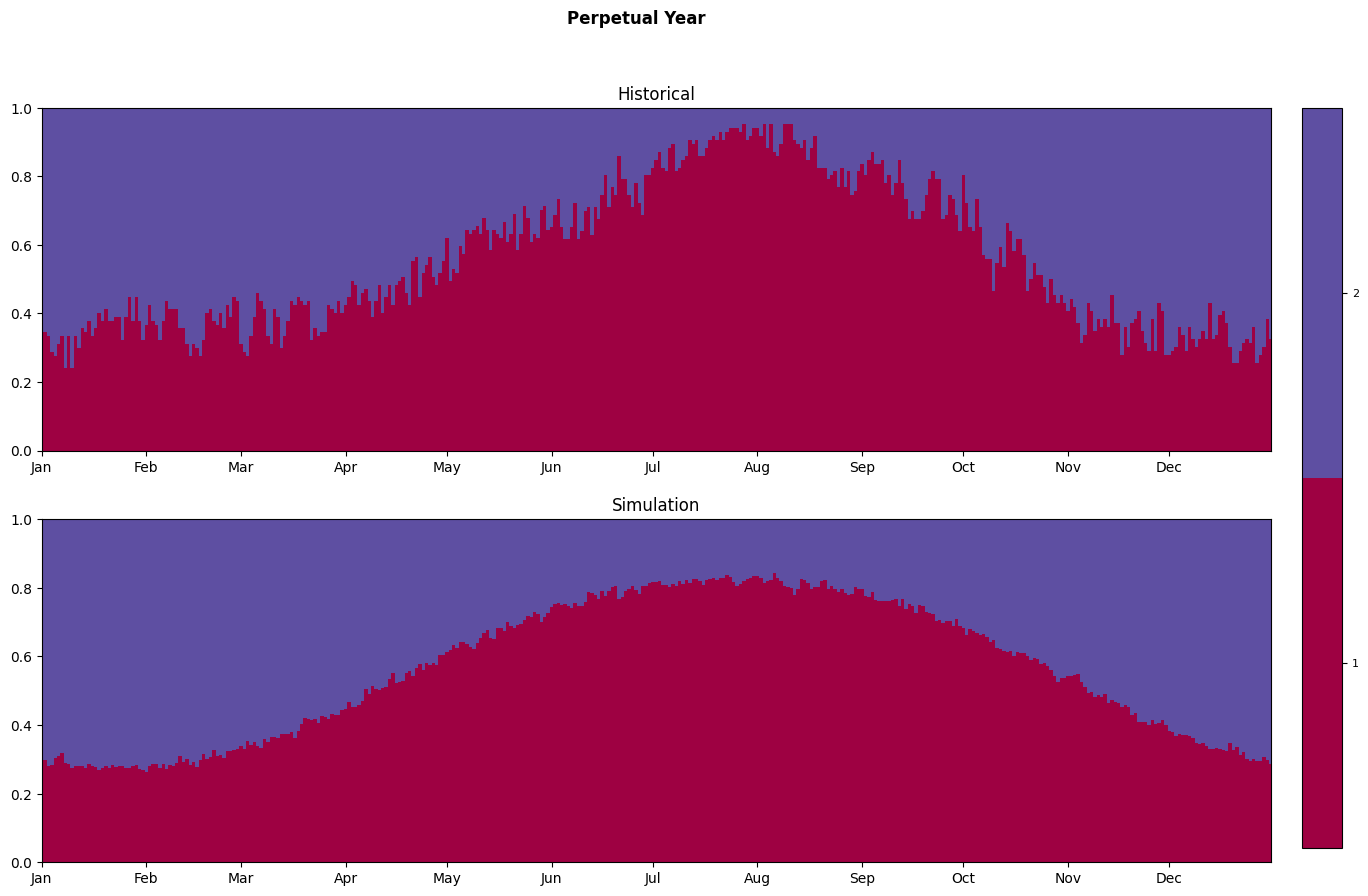

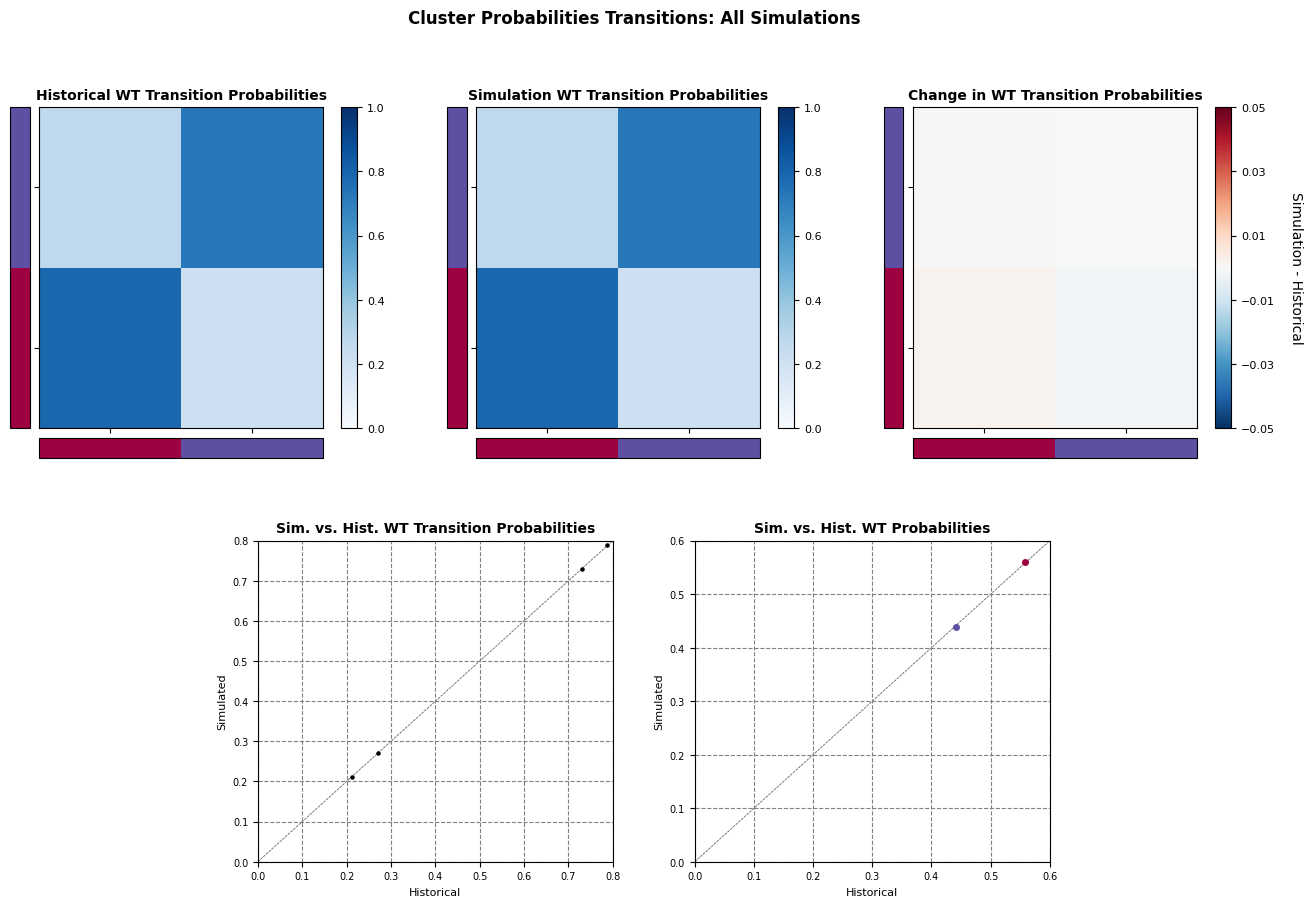

[<Figure size 1585.64x980 with 3 Axes>, <Figure size 1585.64x980 with 14 Axes>]

In [8]:
alr_model.Report_Sim()